In [119]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/stock-market-dataset/symbols_valid_meta.csv
/kaggle/input/stock-market-dataset/stocks/MTL.csv
/kaggle/input/stock-market-dataset/stocks/JOE.csv
/kaggle/input/stock-market-dataset/stocks/DRE.csv
/kaggle/input/stock-market-dataset/stocks/CTY.csv
/kaggle/input/stock-market-dataset/stocks/AMSF.csv
/kaggle/input/stock-market-dataset/stocks/IMH.csv
/kaggle/input/stock-market-dataset/stocks/GFL.csv
/kaggle/input/stock-market-dataset/stocks/CLM.csv
/kaggle/input/stock-market-dataset/stocks/UBER.csv
/kaggle/input/stock-market-dataset/stocks/NEBU.csv
/kaggle/input/stock-market-dataset/stocks/SGB.csv
/kaggle/input/stock-market-dataset/stocks/WWW.csv
/kaggle/input/stock-market-dataset/stocks/UTSI.csv
/kaggle/input/stock-market-dataset/stocks/PBB.csv
/kaggle/input/stock-market-dataset/stocks/UFCS.csv
/kaggle/input/stock-market-dataset/stocks/ZM.csv
/kaggle/input/stock-market-dataset/stocks/DCPH.csv
/kaggle/input/stock-market-dataset/stocks/HALL.csv
/kaggle/input/stock-market-dataset/s

**Import Tools**

In [120]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


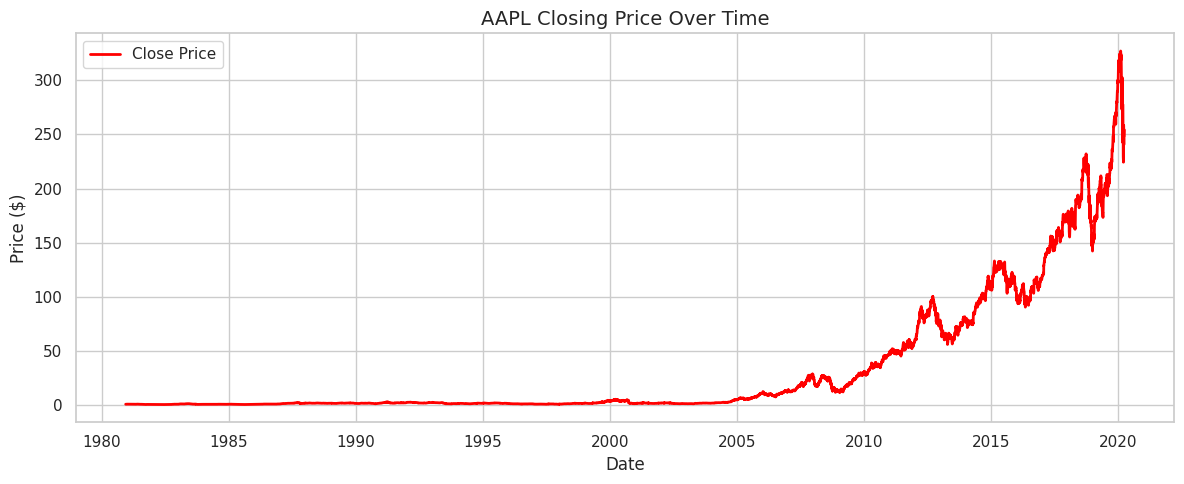

In [121]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("/kaggle/input/stock-market-dataset/stocks/AAPL.csv")

# Keep relevant columns
df = df[['Date', 'Close']].copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.dropna(inplace=True)

# Plot Close Price
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'], label='Close Price', color='red', linewidth=2)
plt.title("AAPL Closing Price Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


**Add SMA 20 and SMA 50**

In [122]:
df['SMA20'] = df['Close'].rolling(window=20).mean()
df['SMA50'] = df['Close'].rolling(window=50).mean()
df.dropna(inplace=True)


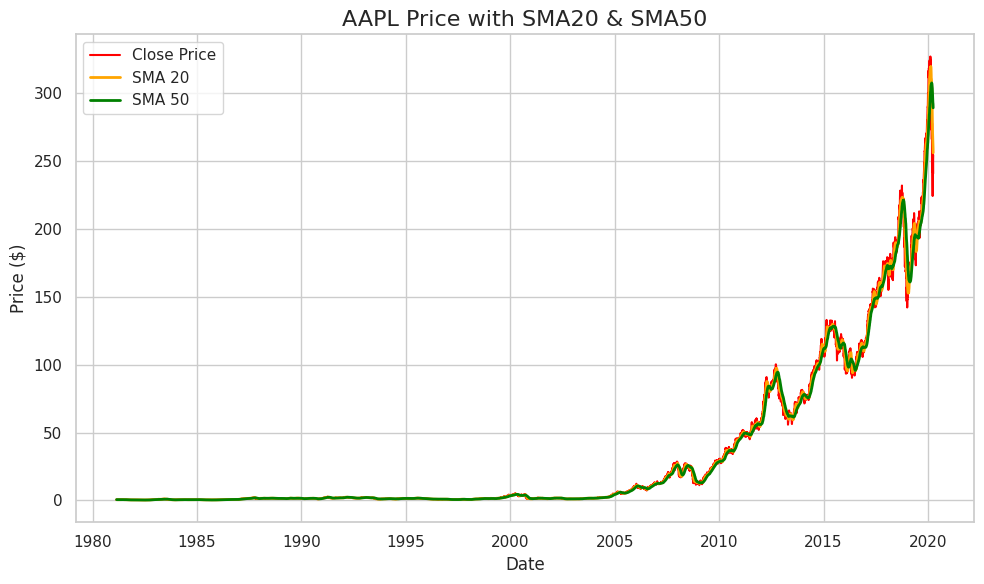

In [123]:
# Plot with SMAs
plt.figure(figsize=(10,6))
plt.plot(df['Date'], df['Close'], label='Close Price',color='red', alpha= 1)
plt.plot(df['Date'], df['SMA20'], label='SMA 20', color='orange', linewidth=2)
plt.plot(df['Date'], df['SMA50'], label='SMA 50', color='green', linewidth=2)
plt.title("AAPL Price with SMA20 & SMA50", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/outputs/aapl_price_with_sma20_and_sma50.png", dpi=300)
plt.show()


In [124]:
# Matplotlib Styling
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style
sns.set(style="whitegrid")


os.makedirs("/kaggle/working/outputs", exist_ok=True)


In [125]:
# Load & Preprocess Data
df = pd.read_csv("/kaggle/input/stock-market-dataset/stocks/AAPL.csv")
df = df[['Date', 'Close']].copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.dropna(inplace=True)


In [126]:
# Prepare Features for Prediction
for i in range(1, 8):  # 7-day window
    df[f'lag_{i}'] = df['Close'].shift(i)

# Remove NaN rows
df.dropna(inplace=True)

X = df[[f'lag_{i}' for i in range(1, 8)]]
y = df['Close']


In [127]:
# Train/Test Split
X_train, X_test = X[:-7], X[-7:]
y_train, y_test = y[:-7], y[-7:]


In [128]:
# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict last 7 days
y_pred = model.predict(X_test)


In [129]:
# Evaluate the Model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print('model evalution')
print(f"📊 MAE: {mae:.2f}")
print(f"📊 RMSE: {rmse:.2f}")
print(f"📊 MAPE: {mape:.2f}%")


model evalution
📊 MAE: 9.37
📊 RMSE: 11.58
📊 MAPE: 3.77%


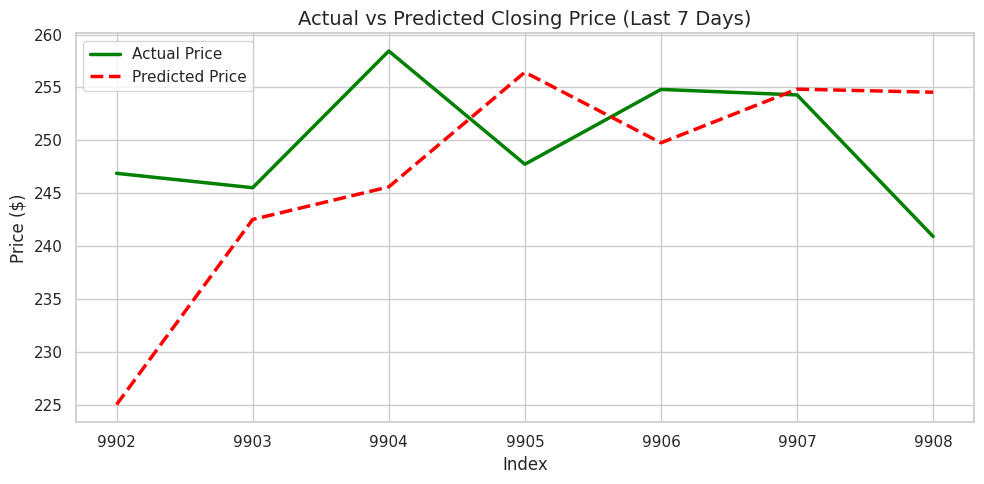

In [130]:
# Actual vs Predicted
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test.values, label='Actual Price', linewidth=2.5, color='green')
plt.plot(y_test.index, y_pred, label='Predicted Price', linewidth=2.5, linestyle='--', color='red')
plt.title("Actual vs Predicted Closing Price (Last 7 Days)", fontsize=14)
plt.xlabel("Index")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/kaggle/working/outputs/actual_vs_predicted_linear.png", dpi=300)
plt.show()


In [135]:
# Generate Buy/Sell Signals
df['Signal'] = 0


df.loc[df['SMA20'] > df['SMA50'], 'Signal'] = 1   # Buy
df.loc[df['SMA20'] < df['SMA50'], 'Signal'] = -1  # Sell

# Track signal changes 
df['Position'] = df['Signal'].diff()


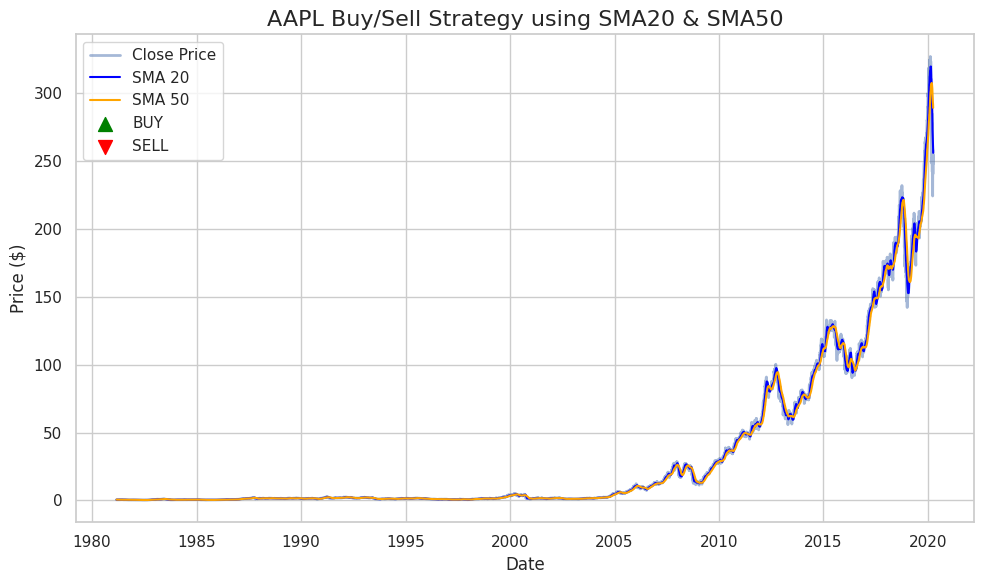

In [136]:
# Plot Buy/Sell Signals on Price Chart
plt.figure(figsize=(10,6))
plt.plot(df['Date'], df['Close'], label='Close Price', alpha=0.5, linewidth=2)
plt.plot(df['Date'], df['SMA20'], label='SMA 20', color='blue', linewidth=1.5)
plt.plot(df['Date'], df['SMA50'], label='SMA 50', color='orange', linewidth=1.5)

# Plot Buy signals )
buy_signals = df[df['Position'] == 1]
plt.scatter(buy_signals['Date'], buy_signals['Close'], label='BUY', marker='^', color='green', s=100)

# Plot Sell signals 
sell_signals = df[df['Position'] == -1]
plt.scatter(sell_signals['Date'], sell_signals['Close'], label='SELL', marker='v', color='red', s=100)

plt.title("AAPL Buy/Sell Strategy using SMA20 & SMA50", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/kaggle/working/outputs/aapl_buy_sell_signals.png", dpi=300)
plt.show()


In [139]:
print("Simple Insight Extraction")
print(f"📈 Total Buy Signals: {len(buy_signals)}")
print(f"📉 Total Sell Signals: {len(sell_signals)}")
print(f"🔍 Strategy covers dates: {df['Date'].min().date()} to {df['Date'].max().date()}")


Simple Insight Extraction
📈 Total Buy Signals: 0
📉 Total Sell Signals: 0
🔍 Strategy covers dates: 1981-03-05 to 2020-04-01
